In [ ]:
import marimo as mo

# Delta-Minimax Group Sequential Design via Constrained Bayesian Optimisation
## Reverse Parameterisation + Failure Region (Error Constraints Only)

This notebook combines two ideas:

1. **Reverse parameterisation** — structural constraints (monotonicity, meeting
point) are satisfied automatically by construction. Every proposed design is
structurally valid. No rejection sampling, no monotonicity penalty.

2. **Constrained BO with failure region** — the error constraints
$\alpha' \leq \alpha^*$ and $\beta' \leq \beta^*$ are handled by fitting a
**VGP classifier** alongside the GPR surrogate. The acquisition function is
$\text{EI} \times \text{PoV}$, where PoV is the probability that a proposed
design satisfies the error constraints. The GPR is trained **only on feasible
designs**, giving it a clean signal about the objective landscape.

This directly addresses the failure of the plain BO approach: the GPR was
overwhelmed by clipped infeasible values (2.0) and could not learn the
objective landscape within the feasible region.

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
import gpflow
from gpflow.keras import tf_keras
import trieste
from trieste.space import Box
from trieste.models.gpflow.models import (
    GaussianProcessRegression,
    VariationalGaussianProcess,
)
from trieste.models import TrainableProbabilisticModel
from trieste.models.optimizer import BatchOptimizer
from trieste.types import Tag
from trieste.acquisition.rule import EfficientGlobalOptimization
from trieste.acquisition import (
    SingleModelAcquisitionBuilder,
    ExpectedImprovement,
    Product,
)

/opt/venv/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from py_group_sequential_designs import generate_boundaries as bd
from py_group_sequential_designs import feasibility_penalty as fp
from py_group_sequential_designs import function_to_minimize as fn_min
from py_group_sequential_designs import simulate as sim
from py_group_sequential_designs import sample_size as ss

# Trial Design Settings

In [ ]:
num_analyses  = 3
target_alpha  = 0.05
target_power  = 0.9
delta1        = 1.0
sigma2        = 3.0

mu = ss.sample_size_means(
    ratio=1, variance=sigma2, power=target_power,
    alpha=target_alpha, delta=delta1
)
print(f"Single-stage sample size mu = {mu:.2f}")

Single-stage sample size mu = 154.15


# Reverse Parameterisation

BO vector: $\tilde{\theta} = (n, c, \Delta u_K, \Delta l_K, \ldots, \Delta u_2, \Delta l_2)$

In [ ]:
def reverse_to_boundaries(params, K):
    params  = np.asarray(params).flatten()
    n       = params[0]
    c       = params[1]
    delta_u = params[2::2][::-1]   # delta_u_2, ..., delta_u_K
    delta_l = params[3::2][::-1]   # delta_l_2, ..., delta_l_K

    upper_bounds = np.array([c + np.sum(delta_u[k:]) for k in range(K)])
    lower_bounds = np.array([c - np.sum(delta_l[k:]) for k in range(K)])
    return n, upper_bounds, lower_bounds


def boundaries_to_reverse(n, upper_bounds, lower_bounds):
    upper_bounds = np.asarray(upper_bounds)
    lower_bounds = np.asarray(lower_bounds)
    K       = len(upper_bounds)
    c       = upper_bounds[-1]
    delta_u = np.diff(upper_bounds[::-1])
    delta_l = np.diff(lower_bounds)[::-1]
    increments      = np.empty(2 * (K - 1))
    increments[0::2] = delta_u
    increments[1::2] = delta_l
    return np.concatenate([[n, c], increments])

# Objective Function

Returns three things for each proposed design:
- **x** — the parameter vector
- **y_obj** — the objective value (only meaningful if feasible)
- **feasible** — 1 if $\alpha' \leq \alpha^*$ and $\beta' \leq \beta^*$, else 0

The GPR is trained only on feasible designs. The VGP classifier is trained
on all designs with the feasibility label.

In [ ]:
def objective(params, mu, target_power, target_alpha, K):
    params      = np.asarray(params).flatten()
    n, upper_bounds, lower_bounds = reverse_to_boundaries(params, K)

    trial = sim.group_sequential_designs(
        n_analyses=K, upper_bounds=upper_bounds, lower_bounds=lower_bounds,
        n_patients=n, null_hypothesis=0, alt_hypothesis=delta1, variance=sigma2
    )
    alpha_prime = trial[1]
    power_prime = trial[2]
    beta_prime  = 1 - power_prime

    # feasibility: both error constraints satisfied
    feasible = int(alpha_prime <= target_alpha and beta_prime <= (1 - target_power))

    max_ess = ss.max_ess(
        n_analyses=K, upper_bounds=upper_bounds, lower_bounds=lower_bounds,
        n_patients=n, null_hypothesis=0, variance=sigma2
    )

    penalty = fp.smooth_penalty(
        mu=mu, power=target_power, alpha=target_alpha,
        beta_prime=beta_prime, alpha_prime=alpha_prime
    )

    y_obj = fn_min.function_to_minimize(max_ess_val=max_ess / mu, penalty=penalty)

    return (
        np.array([params]),       # x: shape (1, 2K)
        np.array([[y_obj]]),      # y_obj: shape (1, 1)
        np.array([[float(feasible)]])  # feasibility label: shape (1, 1)
    )

In [ ]:
# triangular design: used for search space centering and benchmark only
_tri = bd.calculate_triangular_boundaries(
    n_analyses=num_analyses, alpha=target_alpha, delta=delta1, n_patients=20
)
_tri_n, _ = ss.find_sample_size(
    n_analyses=num_analyses, upper_bounds=_tri[0], lower_bounds=_tri[1],
    alt_hypothesis=delta1, variance=sigma2
)
tri_params = boundaries_to_reverse(_tri_n, _tri[0], _tri[1])
c0         = tri_params[1]

_, _y, _feas = objective(tri_params, mu, target_power, target_alpha, num_analyses)
print(f"Triangular benchmark — objective: {_y[0,0]:.4f}, feasible: {bool(_feas[0,0])}")
print(f"Triangular params: {np.round(tri_params, 4)}")

Triangular benchmark — objective: 0.2715, feasible: False
Triangular params: [21.3212  1.8356  0.0379  0.7115  0.2461  1.1241]


# Initialisation

Two-part strategy:
1. **Perturbations** around Pocock, O'Brien-Fleming, and triangular designs
2. **Random feasible points** — pool of 1000 candidates, keep those with
$\alpha' \leq \alpha^*$ and $\beta' \leq \beta^*$

All points feed the **failure (feasibility) dataset**.
Only feasible points feed the **objective dataset**.

In [ ]:
rng_init = np.random.default_rng(seed=42)

# reference designs
_poc   = bd.calculate_pocock_boundaries(n_analyses=num_analyses, alpha=target_alpha, n_patients=20)
_poc_n, _ = ss.find_sample_size(n_analyses=num_analyses, upper_bounds=_poc[0], lower_bounds=_poc[1], alt_hypothesis=delta1, variance=sigma2)
poc_params = boundaries_to_reverse(_poc_n, _poc[0], _poc[1])

_obf   = bd.calculate_of_boundaries(n_analyses=num_analyses, alpha=target_alpha, n_patients=20)
_obf_n, _ = ss.find_sample_size(n_analyses=num_analyses, upper_bounds=_obf[0], lower_bounds=_obf[1], alt_hypothesis=delta1, variance=sigma2)
obf_params = boundaries_to_reverse(_obf_n, _obf[0], _obf[1])

# part 1: perturbations around known designs
all_x, all_y_obj, all_feas = [], [], []
for _ref in [poc_params, obf_params, tri_params]:
    for _ in range(5):
        _p     = _ref + rng_init.normal(scale=0.15, size=len(_ref))
        _p[0]  = np.clip(_p[0],  2.0, mu)
        _p[2:] = np.clip(_p[2:], 0.0, 4.0)
        _x, _y, _f = objective(_p, mu, target_power, target_alpha, num_analyses)
        all_x.append(_x); all_y_obj.append(_y); all_feas.append(_f)

n_feas_perturb = sum(int(_f[0,0]) for _f in all_feas)
print(f"Perturbation points: {len(all_x)} total, {n_feas_perturb} feasible")

# part 2: random feasible points from large pool
# sample uniformly within the search space bounds
n_target  = 15
n_found   = 0
n_tried   = 0
_lb = search_space.lower.numpy()
_ub = search_space.upper.numpy()
_candidates = rng_init.uniform(_lb, _ub, size=(1000, len(_lb)))
for _p in _candidates:
    _x, _y, _f = objective(_p, mu, target_power, target_alpha, num_analyses)
    all_x.append(_x); all_y_obj.append(_y); all_feas.append(_f)
    n_tried += 1
    if int(_f[0, 0]) == 1:
        n_found += 1
    if n_found >= n_target:
        break

print(f"Random feasible points: {n_found} found from {n_tried} candidates")
print(f"Total initial points: {len(all_x)}")

Perturbation points: 15 total, 2 feasible
Random feasible points: 15 found from 87 candidates
Total initial points: 102


In [ ]:
# build the two initial datasets
_all_x_arr    = np.concatenate(all_x)
_all_feas_arr = np.concatenate(all_feas)
_feas_mask    = _all_feas_arr.flatten() == 1

# objective dataset: only feasible points
_obj_x = _all_x_arr[_feas_mask]
_obj_y = np.concatenate(all_y_obj)[_feas_mask]

# failure dataset: all points with feasibility label
initial_data = {
    "objective": trieste.data.Dataset(
        query_points = _obj_x,
        observations = _obj_y
    ),
    "failure": trieste.data.Dataset(
        query_points = _all_x_arr,
        observations = _all_feas_arr
    )
}

print(f"Objective dataset: {_obj_x.shape[0]} feasible points")
print(f"Failure dataset:   {_all_x_arr.shape[0]} total points")
print(f"Objective values: {[round(float(v), 4) for v in _obj_y.flatten()]}")

Objective dataset: 17 feasible points
Failure dataset:   102 total points
Objective values: [0.3794, 0.3777, 0.3929, 0.3281, 0.281, 0.4811, 0.6265, 0.3483, 0.3052, 0.578, 0.343, 0.4567, 0.348, 0.3033, 0.4116, 0.5004, 0.561]


# Search Space

Two options are provided:

**Global search** — wide box covering the full plausible range. Allows the BO
to find designs far from the triangular benchmark, but the feasible region is
sparse and the VGP needs many evaluations to learn its boundary.

**Local search** — tight box centred on the triangular design. The feasible
region is dense within this box, so the VGP learns quickly and the GPR
can focus on refining within a promising neighbourhood. The risk is missing
designs that lie outside the neighbourhood — but given the triangular design
is already approximately optimal, this is unlikely to matter much in practice.

Set `use_local_search = True` for local, `False` for global.

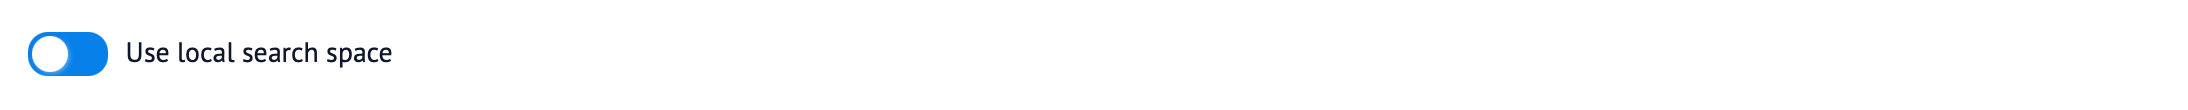

In [ ]:
use_local_search = mo.ui.switch(value=True, label="Use local search space")
use_local_search

In [ ]:
# half-widths for local search — tuned to cover the neighbourhood
# around the triangular design without straying too far
_local_hw_n        = 5.0   # n +/- 5 patients per stage
_local_hw_c        = 0.3   # meeting point +/- 0.3
_local_hw_delta    = 0.3   # each increment +/- 0.3

if use_local_search.value:
    _lower = np.array([
        max(2.0,  tri_params[0] - _local_hw_n),
        c0 - _local_hw_c,
        max(0.0,  tri_params[2] - _local_hw_delta),
        max(0.0,  tri_params[3] - _local_hw_delta),
        max(0.0,  tri_params[4] - _local_hw_delta),
        max(0.0,  tri_params[5] - _local_hw_delta),
    ])
    _upper = np.array([
        min(mu,   tri_params[0] + _local_hw_n),
        c0 + _local_hw_c,
        tri_params[2] + _local_hw_delta,
        tri_params[3] + _local_hw_delta,
        tri_params[4] + _local_hw_delta,
        tri_params[5] + _local_hw_delta,
    ])
    _label = "LOCAL"
else:
    _lower = np.array([2.0,  c0 - 3.0, 0.0, 0.0, 0.0, 0.0])
    _upper = np.array([mu,   c0 + 3.0, 4.0, 4.0, 4.0, 4.0])
    _label = "GLOBAL"

search_space = Box(lower=_lower, upper=_upper)

print(f"Search space ({_label}):")
print(f"  lower: {np.round(search_space.lower.numpy(), 3)}")
print(f"  upper: {np.round(search_space.upper.numpy(), 3)}")
print(f"  width: {np.round(search_space.upper.numpy() - search_space.lower.numpy(), 3)}")
print(f"\nTriangular params for reference:")
print(f"  {np.round(tri_params, 4)}")

Search space (LOCAL):
  lower: [16.321  1.536  0.     0.412  0.     0.824]
  upper: [26.321  2.136  0.338  1.012  0.546  1.424]
  width: [10.     0.6    0.338  0.6    0.546  0.6  ]

Triangular params for reference:
  [21.3212  1.8356  0.0379  0.7115  0.2461  1.1241]


# Models

- **GPR** (Matern52, ARD) trained on feasible designs only
- **VGP** (Squared Exponential, Bernoulli likelihood) trained on all designs
with feasibility label 0/1

In [ ]:
# GPR for the objective
_gpr_kernel = gpflow.kernels.Matern52(
    lengthscales=[1.0] * initial_data["objective"].query_points.shape[1]
)
_gpr = gpflow.models.GPR(
    data=(
        initial_data["objective"].query_points,
        initial_data["objective"].observations
    ),
    kernel=_gpr_kernel,
    likelihood=gpflow.likelihoods.Gaussian()
)

# VGP for feasibility
_vgp_kernel = gpflow.kernels.SquaredExponential(
    lengthscales=[1.0] * initial_data["failure"].query_points.shape[1]
)
_vgp = gpflow.models.VGP(
    data=(
        initial_data["failure"].query_points,
        initial_data["failure"].observations
    ),
    kernel=_vgp_kernel,
    likelihood=gpflow.likelihoods.Bernoulli()
)

models: dict[Tag, TrainableProbabilisticModel] = {
    "objective": GaussianProcessRegression(_gpr),
    "failure":   VariationalGaussianProcess(
        _vgp,
        optimizer=BatchOptimizer(tf_keras.optimizers.Adam(learning_rate=1e-3)),
        use_natgrads=True
    )
}

In [ ]:
class ProbabilityOfValidity(SingleModelAcquisitionBuilder):
    def prepare_acquisition_function(self, model, dataset=None):
        def acquisition(at):
            mean, _ = model.predict_y(tf.squeeze(at, -2))
            return mean
        return acquisition

ei      = ExpectedImprovement()
pov     = ProbabilityOfValidity()
acq_fn  = Product(ei.using("objective"), pov.using("failure"))

rule = EfficientGlobalOptimization(
    acq_fn,
    optimizer=trieste.acquisition.optimizer.generate_continuous_optimizer(
        num_optimization_runs=500
    )
)

# Initialise Ask-Tell Optimiser

In [ ]:
ask_tell = trieste.ask_tell_optimization.AskTellOptimizer(
    search_space     = search_space,
    datasets         = initial_data,
    models           = models,
    acquisition_rule = rule
)

# Bayesian Optimisation Loop

At each iteration:
1. **Ask** for next point (EI × PoV acquisition)
2. **Evaluate** objective and feasibility
3. **Tell** — update both datasets:
   - Feasibility label always goes to the failure dataset
   - Objective value goes to the objective dataset **only if feasible**

In [ ]:
num_repeats   = 500
when_to_print = 50
n_feasible_bo = 0

for _i in range(num_repeats):
    x_new = ask_tell.ask()

    _x, _y_obj, _feas = objective(
        params=x_new, mu=mu,
        target_power=target_power, target_alpha=target_alpha,
        K=num_analyses
    )

    _is_feasible = int(_feas[0, 0]) == 1
    if _is_feasible:
        n_feasible_bo += 1

    # always update failure dataset
    new_data = {
        "failure": trieste.data.Dataset(
            query_points=_x,
            observations=_feas
        )
    }

    # only update objective dataset if feasible
    if _is_feasible:
        new_data["objective"] = trieste.data.Dataset(
            query_points=_x,
            observations=_y_obj
        )
    else:
        # empty dataset to satisfy Trieste's API
        new_data["objective"] = trieste.data.Dataset(
            query_points=np.reshape(np.array([]), (0, _x.shape[1])),
            observations=np.reshape(np.array([]), (0, 1))
        )

    ask_tell.tell(new_data=new_data)

    if (_i + 1) % when_to_print == 0:
        print(f"\nLoop {_i+1} completed. "
              f"Feasible so far: {n_feasible_bo}/{_i+1}", end="")
    elif (_i > when_to_print) and ((_i + 1) % 5 == 0):
        print(".", end="")

print(f"\nOptimisation complete. Total feasible BO proposals: {n_feasible_bo}/{num_repeats}")


Loop 50 completed. Feasible so far: 0/50.........
Loop 100 completed. Feasible so far: 0/100.........
Loop 150 completed. Feasible so far: 0/150......

2026-04-03 19:04:47.912582: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-04-03 19:04:47.916791: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: gpflow.Parameter: the value to be assigned is incompatible with this parameter's transform (the corresponding unconstrained value has NaN or Inf) and hence cannot be assigned. : Tensor had NaN values


InvalidArgumentError: {{function_node __wrapped__CheckNumerics_device_/job:localhost/replica:0/task:0/device:CPU:0}} gpflow.Parameter: the value to be assigned is incompatible with this parameter's transform (the corresponding unconstrained value has NaN or Inf) and hence cannot be assigned. : Tensor had NaN values [Op:CheckNumerics] name

# Results

In [ ]:
final_obj_dataset = ask_tell.to_result().try_get_final_datasets()["objective"]

best_idx    = int(np.argmin(final_obj_dataset.observations.numpy()))
best_params = final_obj_dataset.query_points.numpy()[best_idx]
best_obj    = float(final_obj_dataset.observations.numpy()[best_idx])

best_n, best_upper, best_lower = reverse_to_boundaries(best_params, num_analyses)

print(f"Best objective value: {best_obj:.4f}")
print(f"n per arm per stage:  {best_n:.2f}")
print(f"Upper boundaries:     {np.round(best_upper, 4)}")
print(f"Lower boundaries:     {np.round(best_lower, 4)}")

/tmp/marimo_487/__marimo__cell_xXTn_.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  best_obj    = float(final_obj_dataset.observations.numpy()[best_idx])


Best objective value: 0.2810
n per arm per stage:  20.06
Upper boundaries:     [2.2593 2.0114 1.7911]
Lower boundaries:     [-0.1137  0.8591  1.7911]


In [ ]:
_trial = sim.group_sequential_designs(
    n_analyses=num_analyses, upper_bounds=best_upper, lower_bounds=best_lower,
    n_patients=best_n, null_hypothesis=0, alt_hypothesis=delta1, variance=sigma2
)
print(f"Achieved alpha':  {_trial[1]:.4f}  (target <= {target_alpha})")
print(f"Achieved power':  {_trial[2]:.4f}  (target >= {target_power})")
print()
print("Triangular benchmark:")
print(f"  Upper: [2.1196, 1.8735, 1.8356]")
print(f"  Lower: [0.0000, 1.1241, 1.8356]")
print(f"  n:     ~22,  objective: 0.2715")

Achieved alpha':  0.0477  (target <= 0.05)
Achieved power':  0.9012  (target >= 0.9)

Triangular benchmark:
  Upper: [2.1196, 1.8735, 1.8356]
  Lower: [0.0000, 1.1241, 1.8356]
  n:     ~22,  objective: 0.2715


## Objective function history (feasible designs only)

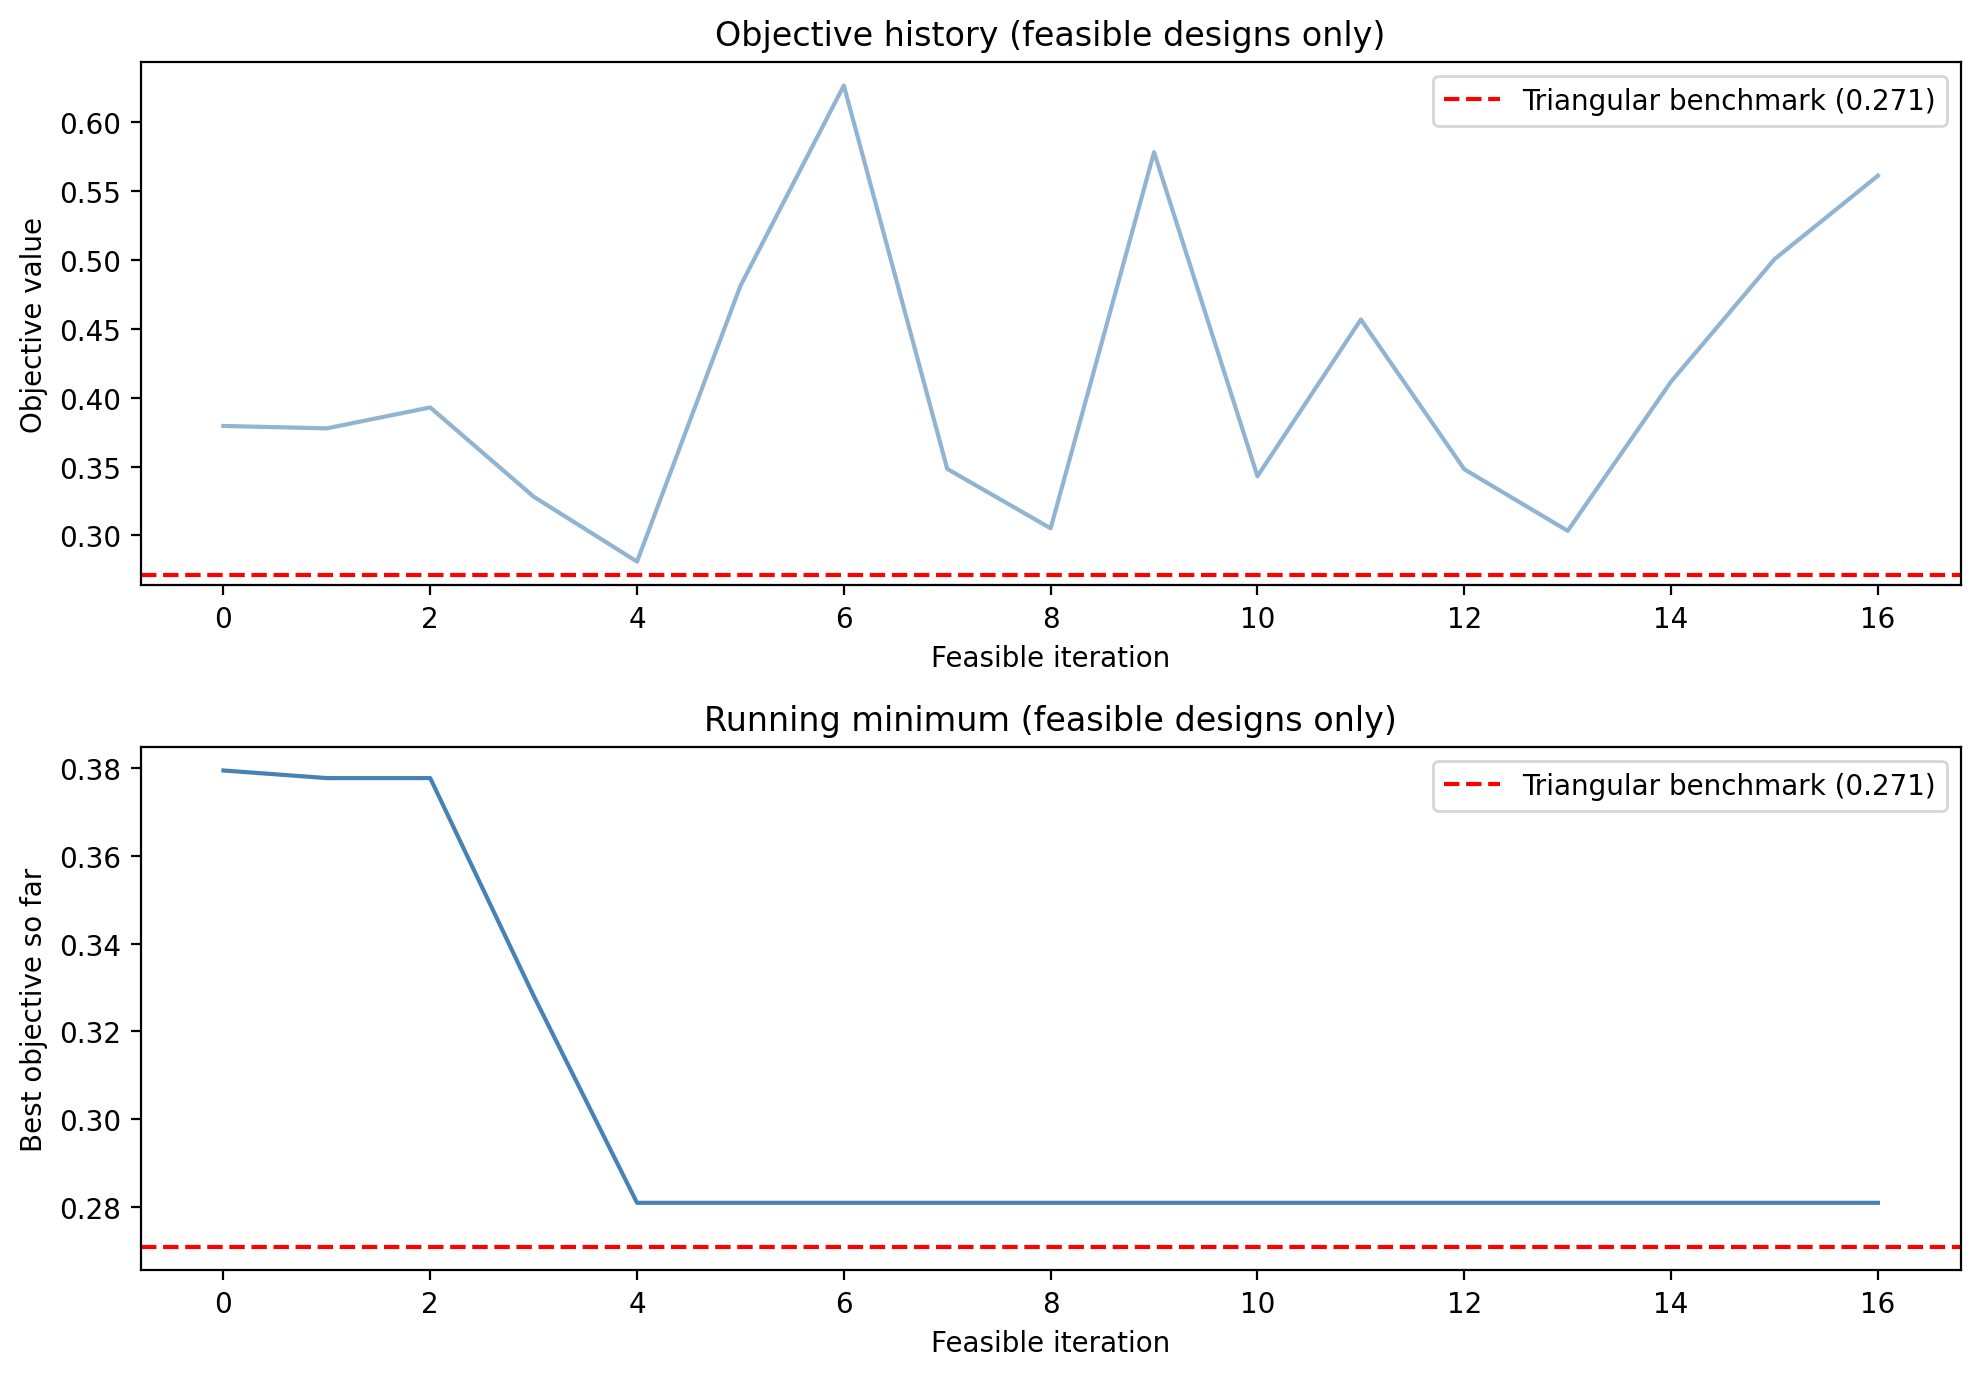

In [ ]:
_obs         = final_obj_dataset.observations.numpy().flatten()
_running_min = np.minimum.accumulate(_obs)

_fig, _axes = plt.subplots(nrows=2, figsize=(10, 7))

_axes[0].plot(_obs, alpha=0.6, color="steelblue")
_axes[0].axhline(y=0.271, color="red", linestyle="--",
                 label="Triangular benchmark (0.271)")
_axes[0].set_xlabel("Feasible iteration")
_axes[0].set_ylabel("Objective value")
_axes[0].set_title("Objective history (feasible designs only)")
_axes[0].legend()

_axes[1].plot(_running_min, color="steelblue")
_axes[1].axhline(y=0.271, color="red", linestyle="--",
                 label="Triangular benchmark (0.271)")
_axes[1].set_xlabel("Feasible iteration")
_axes[1].set_ylabel("Best objective so far")
_axes[1].set_title("Running minimum (feasible designs only)")
_axes[1].legend()

_fig.tight_layout()
_fig

## Best design vs triangular benchmark

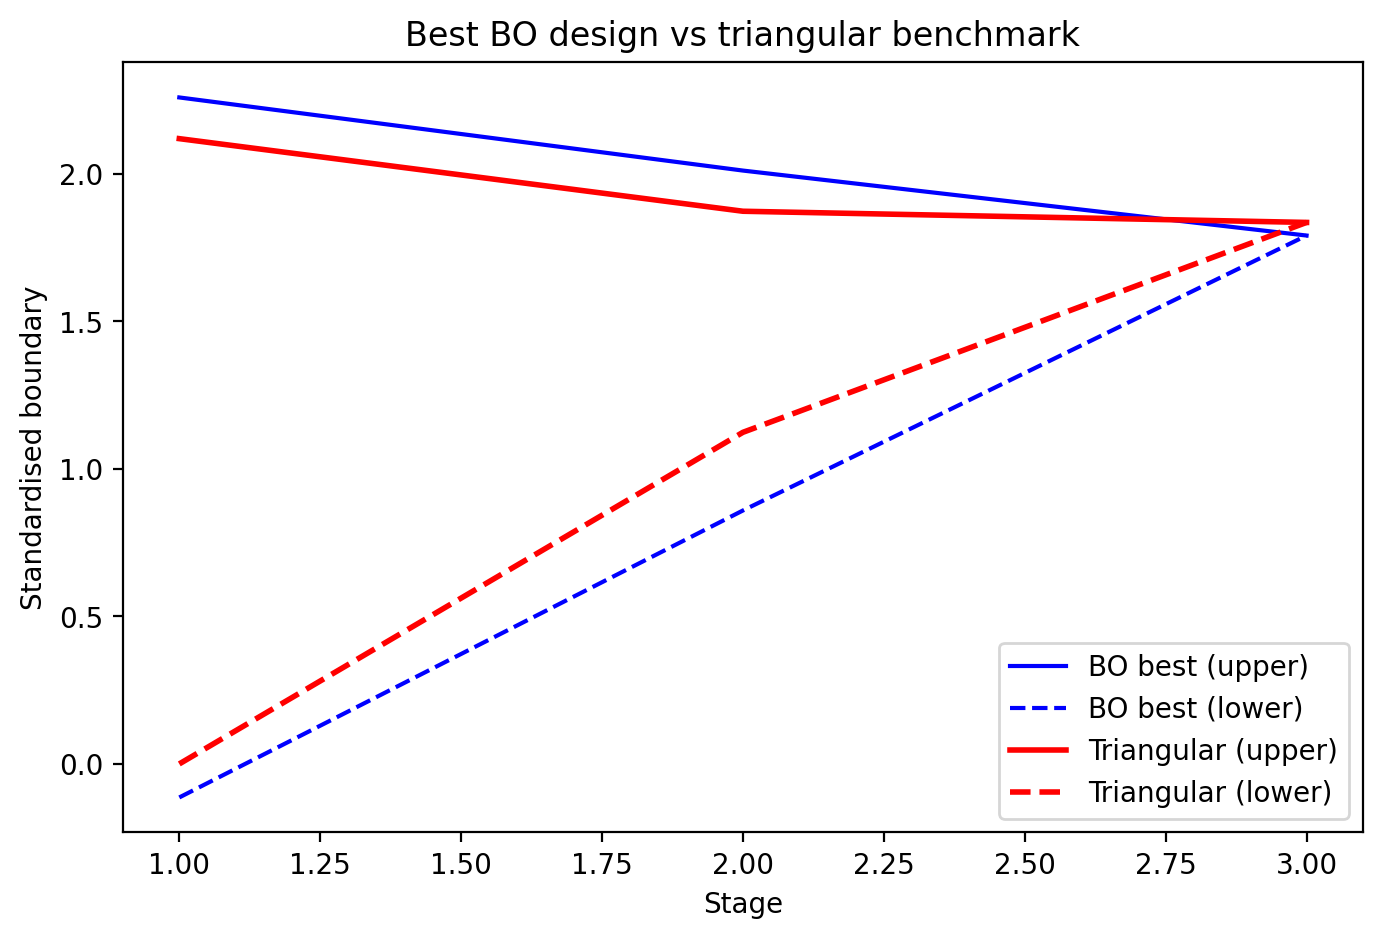

In [ ]:
_fig, _ax = plt.subplots(figsize=(8, 5))

_ax.plot([1, 2, 3], best_upper, color="blue", label="BO best (upper)")
_ax.plot([1, 2, 3], np.concatenate((best_lower[:2], [best_upper[2]])),
         color="blue", linestyle="--", label="BO best (lower)")
_ax.plot([1, 2, 3], [2.1196, 1.8735, 1.8356], color="red",
         linewidth=2, label="Triangular (upper)")
_ax.plot([1, 2, 3], [0.0, 1.1241, 1.8356], color="red",
         linewidth=2, linestyle="--", label="Triangular (lower)")

_ax.set_xlabel("Stage")
_ax.set_ylabel("Standardised boundary")
_ax.set_title("Best BO design vs triangular benchmark")
_ax.legend()
_fig

# Save Results

In [ ]:
_datasets = ask_tell.to_result().try_get_final_datasets()

# save objective dataset (feasible designs only)
_obj = _datasets["objective"]
_obj_df = pd.DataFrame(
    data=_obj.query_points.numpy(),
    columns=["n", "c", "delta_u3", "delta_l3", "delta_u2", "delta_l2"]
)
_obj_df["obj_f"] = _obj.observations.numpy()
_obj_df.to_csv("/tf/paul/constrained_bo_objective.csv", index=False)

# save failure dataset (all designs with feasibility label)
_fail = _datasets["failure"]
_fail_df = pd.DataFrame(
    data=_fail.query_points.numpy(),
    columns=["n", "c", "delta_u3", "delta_l3", "delta_u2", "delta_l2"]
)
_fail_df["feasible"] = _fail.observations.numpy().astype(int)
_fail_df.to_csv("/tf/paul/constrained_bo_failure.csv", index=False)

print(f"Saved {_obj_df.shape[0]} feasible designs to constrained_bo_objective.csv")
print(f"Saved {_fail_df.shape[0]} total designs to constrained_bo_failure.csv")
print(f"Feasibility rate: {_fail_df['feasible'].mean():.1%}")

Saved 17 feasible designs to constrained_bo_objective.csv
Saved 287 total designs to constrained_bo_failure.csv
Feasibility rate: 5.9%
